# AG-HYPOPT · Trial 06

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Five trials recorded; best is trial 05 (0.0196). Trial 01 (lr_mu 10.09, sigma_ref 10.25, gamma_anneal 0.10) 0.0981. Trial 02 (lr_mu 25.36, sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20) 0.0246. Trial 03 (lr_mu 23.05, sigma_ref 9.37, lr_gamma 0.79, gamma_anneal 0.22) 0.0477. Trial 04 (lr_mu 29.41, sigma_ref 6.62, lr_gamma 0.61, gamma_anneal 0.71) 0.0262. Trial 05 (lr_mu 26.99, sigma_ref 6.28, lr_gamma 0.42, gamma_anneal 0.42) 0.0196, the new best (mu 15.3%, gamma 12.6%). The uniform phase is complete (5/5), so this trial is the first with TPE ('trials') proposals: cell 2 now draws from the Good model and prints an ei score per candidate (the batch is in draw order, not sorted). Empirical pattern: lr_mu is the dominant lever with an optimum near 27 (10 -> 0.098, 23 -> 0.048, 25 -> 0.025, 27 -> 0.020, 29 -> 0.026); low sigma_ref (~6-7) is favourable; gamma responds weakly to lr_gamma; residual error stays at Trans05 (mu -28% to -38%).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_06'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (5/5 trials)
ID |     ei | params
 1 | 2.1973 | {"gamma_anneal": 0.4833155115836798, "lr_gamma": 0.4995974124703059, "lr_mu": 26.818823006650042, "sigma_ref": 7.636430571625812}
 2 | 2.2356 | {"gamma_anneal": 0.47283900716258653, "lr_gamma": 0.8801530774470296, "lr_mu": 29.469189054632416, "sigma_ref": 6.66387299225155}
 3 | 1.0866 | {"gamma_anneal": 0.15557944965523104, "lr_gamma": 0.4891127371636964, "lr_mu": 28.720916528763, "sigma_ref": 14.945358254829472}
 4 | 2.8447 | {"gamma_anneal": 0.4272507440595979, "lr_gamma": 0.8929488628119009, "lr_mu": 15.99144393780724, "sigma_ref": 6.678834943235513}
 5 | 1.4466 | {"gamma_anneal": 0.6652233681199663, "lr_gamma": 0.6313976900041638, "lr_mu": 26.33388643392835, "sigma_ref": 5.603783550972231}
 6 | 0.6122 | {"gamma_anneal": 0.6609668958367043, "lr_gamma": 0.8933240975287313, "lr_mu": 26.845904616342988, "sigma_ref": 9.776111891088007}
 7 | 1.3780 | {"gamma_anneal": 0.4430664594534053, "lr_gamma": 0.7540956968235764, "lr_mu

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 05 (0.0196: lr_mu 26.99, sigma_ref 6.28, lr_gamma 0.42, gamma_anneal 0.42). The five trials identify the good region: lr_mu ~27 (clear peak; 23 or less and 29 both worse), sigma_ref ~6-7, lr_gamma ~0.42-0.5, gamma_anneal ~0.2-0.4. This is the first TPE batch. The ei column is in draw order, so I read it by value: the three highest-ei candidates are #4 (2.84), #2 (2.24) and #1 (2.20), but #4 has lr_mu 16 - a region already shown poor (lr_mu 10 -> 0.098, 23 -> 0.048) - so I do not trust that top-ranked draw with only five data points. The candidate that makes the most sense is the one matching the established optimum: candidate 1 (lr_mu 26.82, sigma_ref 7.64, lr_gamma 0.4996, gamma_anneal 0.483) keeps lr_mu at the proven peak and sits in the empirically-good sigma_ref/lr_gamma/gamma_anneal band, giving the strongest chance to match or edge past trial 05. Candidate 2 (lr_mu 29.47, lr_gamma 0.88) and candidate 6 (lr_mu 26.85 but sigma_ref 9.78, lr_gamma 0.89) push lr_mu/lr_gamma into regions already seen to hurt. I choose candidate 1.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4833155115836798, 'lr_gamma': 0.4995974124703059, 'lr_mu': 26.818823006650042, 'sigma_ref': 7.636430571625812}
Running  1nW Trans05 ... 

μ 9.39 -> 6.12 | γ 8.5 -> 8.81 | NLL 1.43


Running  1nW Trans20 ... 

μ 17.32 -> 14.51 | γ 8.5 -> 8.75 | NLL 2.60


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 93.66 | γ 14.1 -> 14.23 | NLL 3.38


Running 3nW Trans100 ... 

μ 175.71 -> 148.50 | γ 14.1 -> 14.13 | NLL 2.90



Total: 7.0 min


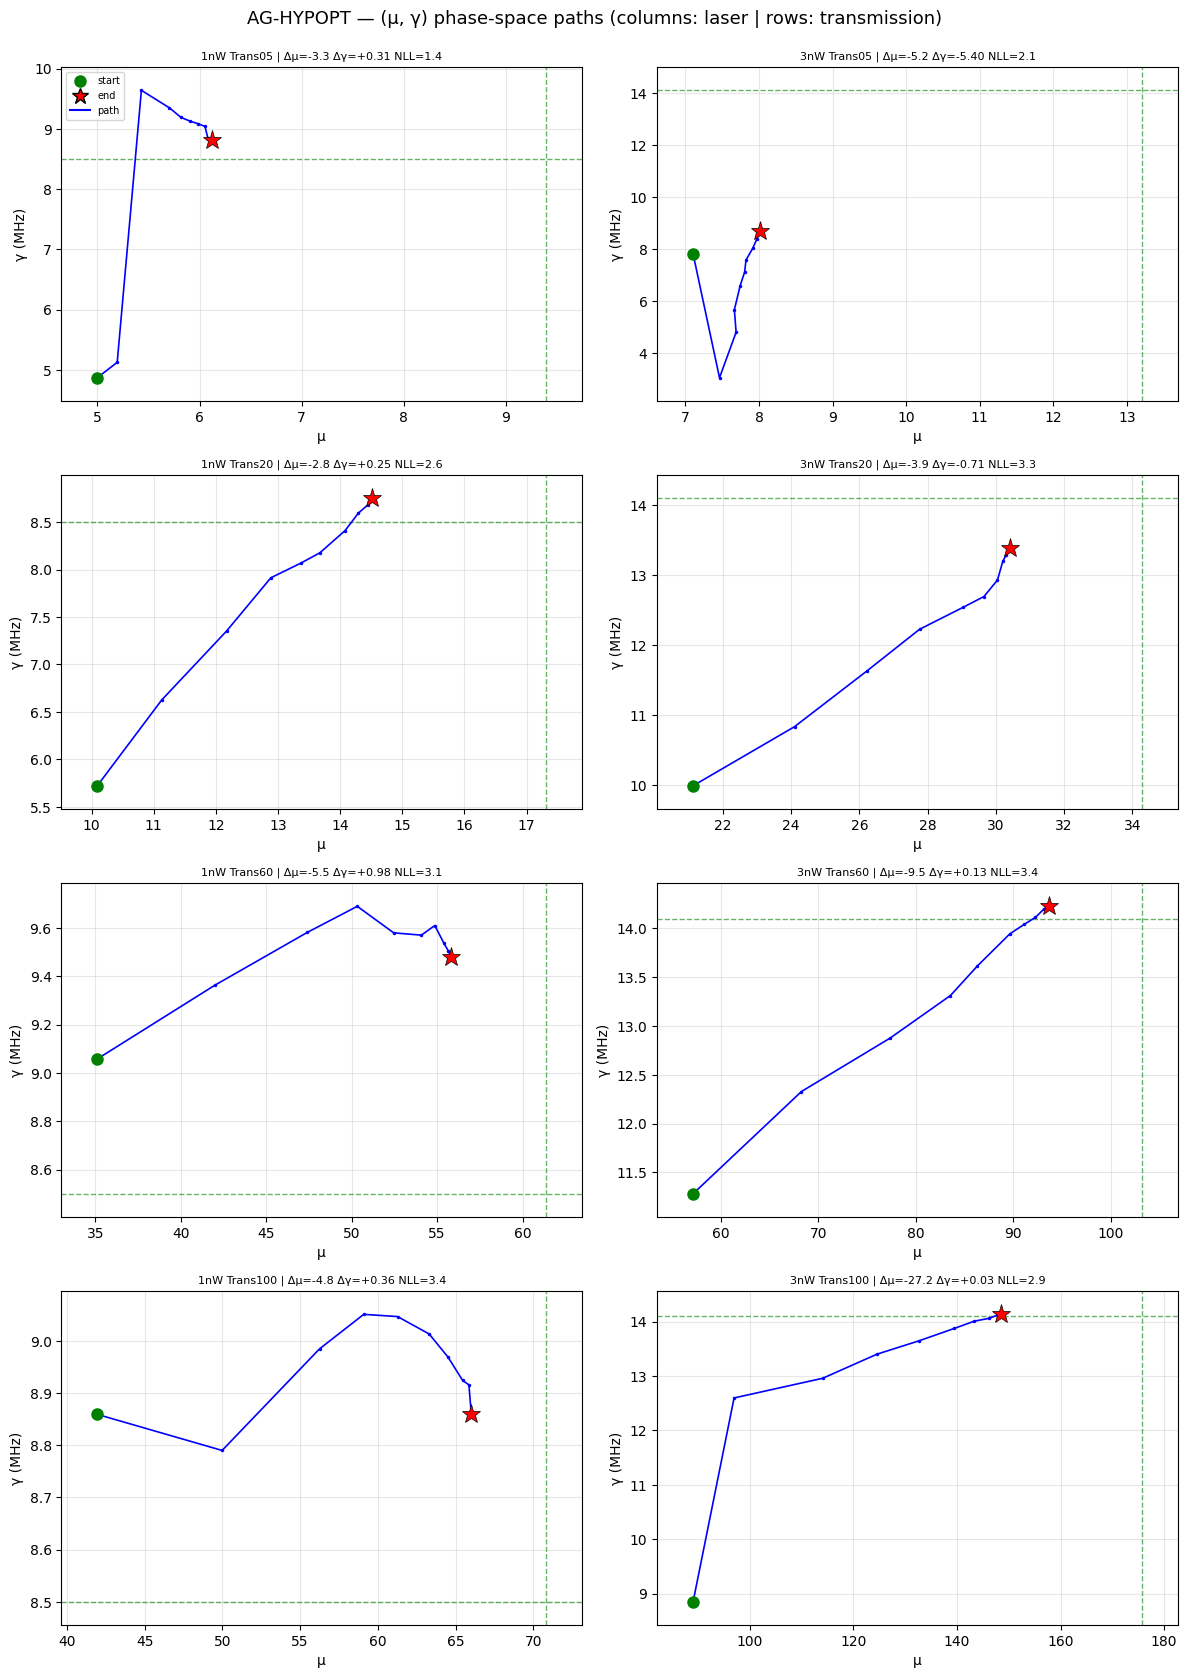

trial finished in 7.0 min
objective = 0.0329 ± 0.0136
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.12   -34.8 |     8.50    8.81    +3.6
1nW Trans20    17.32   14.51   -16.2 |     8.50    8.75    +2.9
1nW Trans60    61.37   55.83    -9.0 |     8.50    9.48   +11.5
1nW Trans100   70.82   66.01    -6.8 |     8.50    8.86    +4.2
3nW Trans05    13.20    8.01   -39.4 |    14.10    8.70   -38.3
3nW Trans20    34.28   30.42   -11.3 |    14.10   13.39    -5.0
3nW Trans60   103.20   93.66    -9.2 |    14.10   14.23    +0.9
3nW Trans100  175.71  148.50   -15.5 |    14.10   14.13    +0.2

μ: RMSE 10.873 (rel 21.2%, bias -7.779) | γ: RMSE 1.968 (rel 14.4%, bias -0.507)


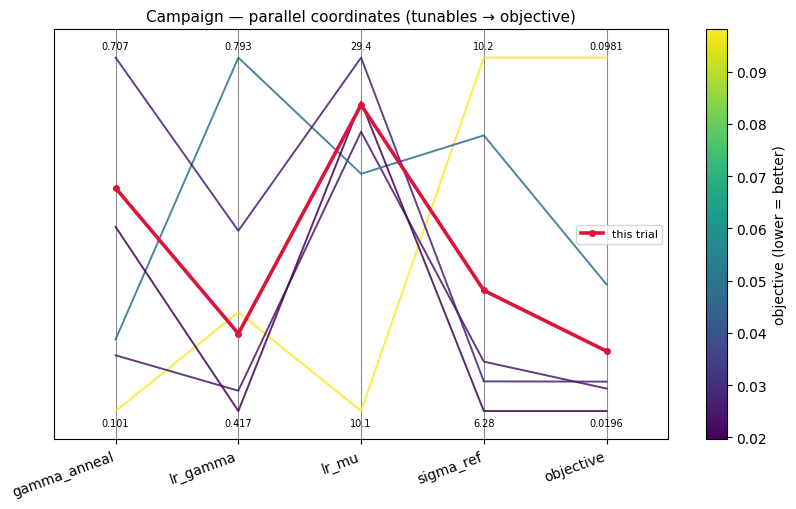

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 06 (sigma_ref 7.64, lr_mu 26.82, lr_gamma 0.50, gamma_anneal 0.48), the first TPE-phase choice, ran 7.0 min and scored 0.0329 +/- 0.0136, worse than trial 05 (0.0196) but better than trials 03 and 01. I picked it as the candidate closest to the empirical optimum; it differs from trial 05 mainly by sigma_ref (7.64 vs 6.28), with small rises in lr_gamma and gamma_anneal. Both terms regressed: mu rel RMSE 15.3% -> 21.2% (bias -7.8), gamma 12.6% -> 14.4%. The mu regression lines up with the sigma_ref trend across the campaign: mu error vs sigma_ref is 6.28 -> 15.3% (05), 6.62 -> 17.2% (04), 6.84 -> 17.5% (02), 7.64 -> 21.2% (06), 9.37 -> 27.7% (03), i.e. monotone - smaller sigma_ref is better - so sigma_ref is a genuine lever, not an artefact of the earlier confounds. gamma was again weakest at 3nW Trans05 (-38%) and 1nW Trans60 (+12%). The TPE batch's lowest-ei draw (#4, lr_mu 16) was avoided because lr_mu 16 is in the region already shown poor; this trial gives no evidence it would have been better.

**Summary:** Trial 06 (sigma_ref 7.64, lr_mu 26.82, lr_gamma 0.50, gamma_anneal 0.48) scored 0.0329 +/- 0.0136, worse than trial 05, and confirms sigma_ref as a monotone mu lever (mu rel RMSE rises 15.3% -> 21.2% as sigma_ref goes 6.28 -> 7.64).
**Key insight:** sigma_ref is a strong, monotone mu lever (smaller is better); the optimum sits at sigma_ref below trial 05's 6.28.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 06 (sigma_ref 7.64, lr_mu 26.82, lr_gamma 0.50, gamma_anneal 0.48) scored 0.0329 +/- 0.0136, worse than trial 05, and confirms sigma_ref as a monotone mu lever (mu rel RMSE rises 15.3% -> 21.2% as sigma_ref goes 6.28 -> 7.64).'
KEY_INSIGHT = 'sigma_ref is a strong, monotone mu lever (smaller is better); the optimum sits at sigma_ref below trial 05 value of 6.28.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_06 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_07.ipynb. Open it and follow its cells from the top.
